# Tutorial: accelerating ultranest with simulation-based inference (SBI)

In this tutorial you will learn:

 - How to specify a mock data generator in addition to the likelihood
 - How to train a simulation-based inference model to predict a posterior distribution (neural posterior estimation)
 - How to verify that the simulation-based inference trained well
 - How to use SBI-NPE to accelerate the UltraNest nested sampling run

In this example, we fit a Voigt line in a spectrum.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import ultranest
import ultranest.simbase.minisbi

rng = np.random.default_rng(123)

## Defining the model

### Gaussian measurement noise

First, we need our physical model function of the intrinsic spectrum, and also predict the noise level. We assume a Voigt line shape and constant noise.

In [2]:
noise_std = 0.1

In [3]:
N_DATA = 1000
x = np.geomspace(0.55, 0.75, N_DATA)

In [4]:
parameter_names = ["amplitude", "center_x", "width", "background", "slope"]
N_PARAMS = len(parameter_names)

Define the model spectrum function, given model parameters

In [5]:
from scipy.special import voigt_profile

In [6]:
sigma_instrumental = 0.001 # nominal resolution of the spectrograph

In [41]:
def generate_mean_and_noise(theta, idx=0, seed=0):
    amplitude, center_x, width, background, slope = theta
    signal = amplitude * voigt_profile(x - center_x, sigma_instrumental, width) + background + (x / center_x) ** slope

    return {
        'mean':      signal,
        'noise_std': signal * 0 + noise_std,  # same noise for each data point
    }

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


The received idx and seed are not used here. They are integers, in case randomness in the physics model is needed.

Our true parameters for this example:

In [8]:
theta_true = [0.0042, 0.656279, 0.001, 0.2, -1.]

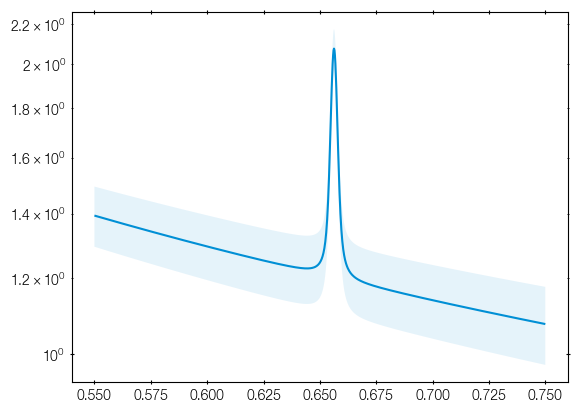

In [9]:
plt.errorbar(
    x=x,
    y=generate_mean_and_noise(theta_true)['mean'],
    capsize=0,
)
plt.fill_between(
    x,
    generate_mean_and_noise(theta_true)['mean'] - generate_mean_and_noise(theta_true)['noise_std'],
    generate_mean_and_noise(theta_true)['mean'] + generate_mean_and_noise(theta_true)['noise_std'],
    alpha=0.1,
)
plt.yscale('log');

A beautiful spectrum of a line, on top of a slightly sloped continuum.

### Prior distribution

Define our prior distribution as usual, based on unit cube transforms.

In [10]:
def prior_transform(u):
    result = u.copy()
    # amplitude (index 0): log-uniform [1e-2, 1e2]
    result[0] = 10**(-4 + u[0] * 4)
    # center_x (index 1): uniform [0.65, 0.66]
    result[1] = 0.65 + u[1] * 0.01
    # width (index 2): uniform [1e-4, 0.01]
    result[2] = 10**(-4 + 2 * u[2])
    # background level (index 3): uniform [-1, 1]
    result[3] = -1 + 2 * u[3]
    # slope (index 4): uniform [-2, +2]
    result[4] = -2 + 4 * u[4]
    return result


## Generate noisy data

### The observed data we will fit

Going from the model above to data is trivial, with a Gaussian random number generator:

In [11]:
def inject_noise(mean_props, rng):
    return rng.normal(mean_props['mean'], mean_props['noise_std'])

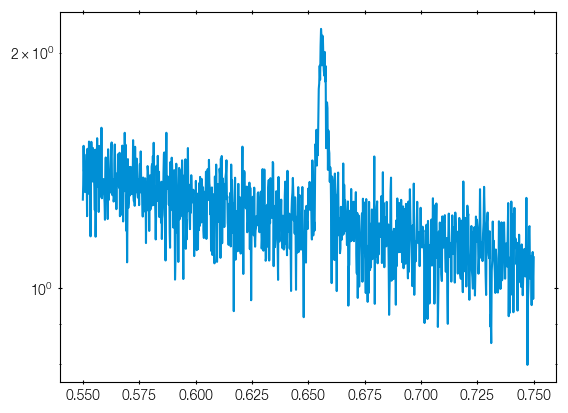

In [12]:
obs_spectrum = inject_noise(generate_mean_and_noise(theta_true), rng)

plt.plot(x, obs_spectrum)
plt.yscale('log')

### Generate mock data - Prior predictive checks

Here are some example data sets when we sampled from the prior. These show the diversity of data we consider reasonable a priori:

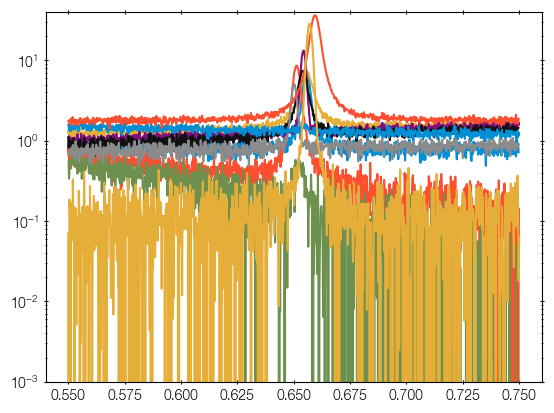

In [13]:
for i in range(10):
    u = rng.uniform(size=N_PARAMS)
    params = prior_transform(u)
    plt.plot(x, inject_noise(generate_mean_and_noise(params), rng))
    plt.yscale('log')
    plt.ylim(1e-2, 40)

## Data likelihood

We adopt a corresponding Gaussian likelihood function, that we will use at the end with ultranest to improve upon the SBI approach.

In [14]:
def loglikelihood(mean_props, noisy_data):
    # the usual Gaussian likelihood function, comparing data to the model, under noise
    return np.sum(
        -0.5 * np.log(2.0 * np.pi)
        - np.log(mean_props['noise_std'])
        - 0.5 * ((noisy_data - mean_props['mean']) / mean_props['noise_std']) ** 2
    )

## Simulation-based inference

The simulation-based inference trains a neural network to predict a simple factorized posterior distribution on the unit hypercube. 

The training pipeline is highly efficient, reusing generated model with different noise.

Sampled datasets will be cached internally to a folder.

In [15]:
folder = 'mygaussline'

In [16]:
# optional: clear cache whenever you change the prior or model function
!rm -rf mygaussline/

This happens efficiently in batches (using joblib.Memory). Some helper functions that call our functions in a loop:

In [17]:
from ultranest.simbase.minisbi.utils import make_memory, make_cached_generate

In [18]:
memory = make_memory(folder)
generate_noiseless_batch = make_cached_generate(
    memory, prior_transform, generate_mean_and_noise
)

### Training the model

Next train a simple neural network to predict a posterior distribution.

In [19]:
from ultranest.simbase.minisbi.npe import train_npe

In [20]:
model = train_npe(
    # our folder
    folder=folder,
    # our (costly) model function
    generate_noiseless_batch=generate_noiseless_batch,
    # our cheap noisy generator:
    inject_noise=inject_noise,
    # our model parameters
    n_params=N_PARAMS,

    # Parameters related to training strategy:

    # seed for randomness
    base_seed=12345,
    # how long to train: Choose how long you want to wait - the higher the better.
    max_model_evals=100000,
    # optional: if > 1, evaluate models in parallel (with joblib.Parallel)
    num_processes=1,
    # the full history of noise-free models generated with generate_mean_and_noise is kept.
    # they are reused and additional datasets are generated with fresh noise
    # fresh_example_fraction sets the balance between freshly generated models and reuse of previously generated models
    # if the model is cheap, can be 1.0. 
    # Probably should not be much lower than 0.001. -- if the loss becomes extremely small (-300), the network memorized all samples.
    fresh_example_fraction=0.01,
    # choose how many new samples are generated in each epoch
    # this sets the number of model evaluations per epoch
    # Note: This sets the batch size seen by the network in each evaluation, by batch_size=fresh_sim_batch_size / fresh_example_fraction - you probably want batch_size of O(1000)
    fresh_sim_batch_size=32,
    # neural network training is somewhat stochastic and may not give an improvement in each epoch
    # set the patience to how many epochs to wait for a significant improvement
    # in any case, the best neural network is kept.
    patience=10,
    # what loss improvement is designated a substantial improvement
    patience_min_delta=0.01,

    # parameters for the neural network architecture and learning

    # learning rate - need to chose this depending on the batch size. 
    # Increase if loss is changing slowly, decrease if the loss becomes erratic. 
    # Try 1e-3, 1e-4, etc.
    npe_lr=3e-4,
    # maximum width of the layers, 1024 is a decent default, but worth trying other values
    npe_width=512,
    # maximum number of layers. 'cascade' is not very sensitive to this parameter.
    npe_depth=6,
    # shape: 
    # - 'rectangular' - a classic MLP where each of the npe_depth layer has npe_width neurons
    # - 'triangular' - a funnel-shaped MLP, with each next layer decreasing linearly in width
    # - 'cascade' - subsequent layers are half the width, half the neurons are forwarded to the next layer, the other half skip to the final layer.
    # 'cascade' is recommended, because it avoids having to play much with npe_width and npe_depth - it contains both a wide and a deep network.
    # the neural network layers can be of equal layer width
    layer_shape='cascade',
    # activation function
    npe_activation_cls='ReLU',
)

fresh_example_fraction=0.010  =>  n_fresh=32, replay_example_count=3168 per sub-batch
Starting parallel simulation generator (3220 batches total, 1 workers) …
Detected n_data=1000 from probe simulation.
hidden layer widths: [512, 256, 128, 64, 32, 16]
Training NPE (product of Kumaraswamy-Logistic distributions) with on-the-fly batch generation …
Computing normalisation statistics …
[ZScoreNorm] fitted 1000 features from 2000 samples.
  mean : min=1.023231  max=10.345800
  std  : min=0.592311   max=27.783062
Input normalisation fitted.
Generating fixed NPE validation set (val_size=1024) …
Training NPE with on-the-fly batch generation …
  Epoch   1/390  train_loss=-1.1824  val_loss=-1.5215  fresh_simulator_evals=256  *
  Epoch   2/390  train_loss=-2.1619  val_loss=-2.2636  fresh_simulator_evals=512  *
  Epoch   3/390  train_loss=-2.7500  val_loss=-2.5668  fresh_simulator_evals=768  *
  Epoch   4/390  train_loss=-2.9596  val_loss=-2.7459  fresh_simulator_evals=1024  *
  Epoch   5/390  tra

The meaning of the training output is as follows:

The **loss** is the log-density of the predicted posterior distribution at the true parameter values.

The **training loss** is what the optimizer sees. Ideally, this should not stall.

The **validation loss** is the posterior density of independent samples generated at the beginning and kept separate. These mock data and their true parameters are not seen by the training and kept fixed. The validation loss should keep improving (decreasing).

The **fresh_simulator_evals** gives the number of model calls performed so far.

The last column gives a star when the model is improving, and otherwise counting up until *patience* epochs give no improvements.

At the end, the best model is kept.

## SBI-NPE posterior distribution

The neural posterior may loose a lot of information, may be biased, etc. We will check this below.

But let's apply the neural model to our data and see what we get:

In [21]:
from ultranest.simbase.minisbi.npe import sample_posterior

posterior_samples_u, posterior_samples_theta = sample_posterior(
    model=model,
    observed_data=obs_spectrum,
    prior_transform=prior_transform,
    n_params=N_PARAMS,
    n_posterior_samples=100000,
)


Predicted posterior (Kumaraswamy-Logistic product, unit-cube space):
  Param 0: loc=0.9677  scale=0.2043  a=1.0741  b=0.2385
  Param 1: loc=0.2767  scale=0.0919  a=1.3752  b=3.7631
  Param 2: loc=0.1950  scale=0.0941  a=1.5721  b=5.2342
  Param 3: loc=0.5873  scale=0.0044  a=0.2282  b=0.4277
  Param 4: loc=0.3659  scale=0.0136  a=0.4344  b=0.2741


/home/user/Downloads/mininest/ultranest/simbase/minisbi/logistic.py:37: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500.0, 500.0)))


In [22]:
print("Posterior summary:")
for i, name in enumerate(parameter_names):
    samp = posterior_samples_theta[:, i]
    print(f"  {name:12s}: mean={samp.mean():.3f}  std={samp.std():.3f}"
          f"  true={theta_true[i]:.3f}")

Posterior summary:
  amplitude   : mean=0.006  std=0.018  true=0.004
  center_x    : mean=0.655  std=0.002  true=0.656
  width       : mean=0.001  std=0.002  true=0.001
  background  : mean=0.209  std=0.008  true=0.200
  slope       : mean=-1.009  std=0.044  true=-1.000


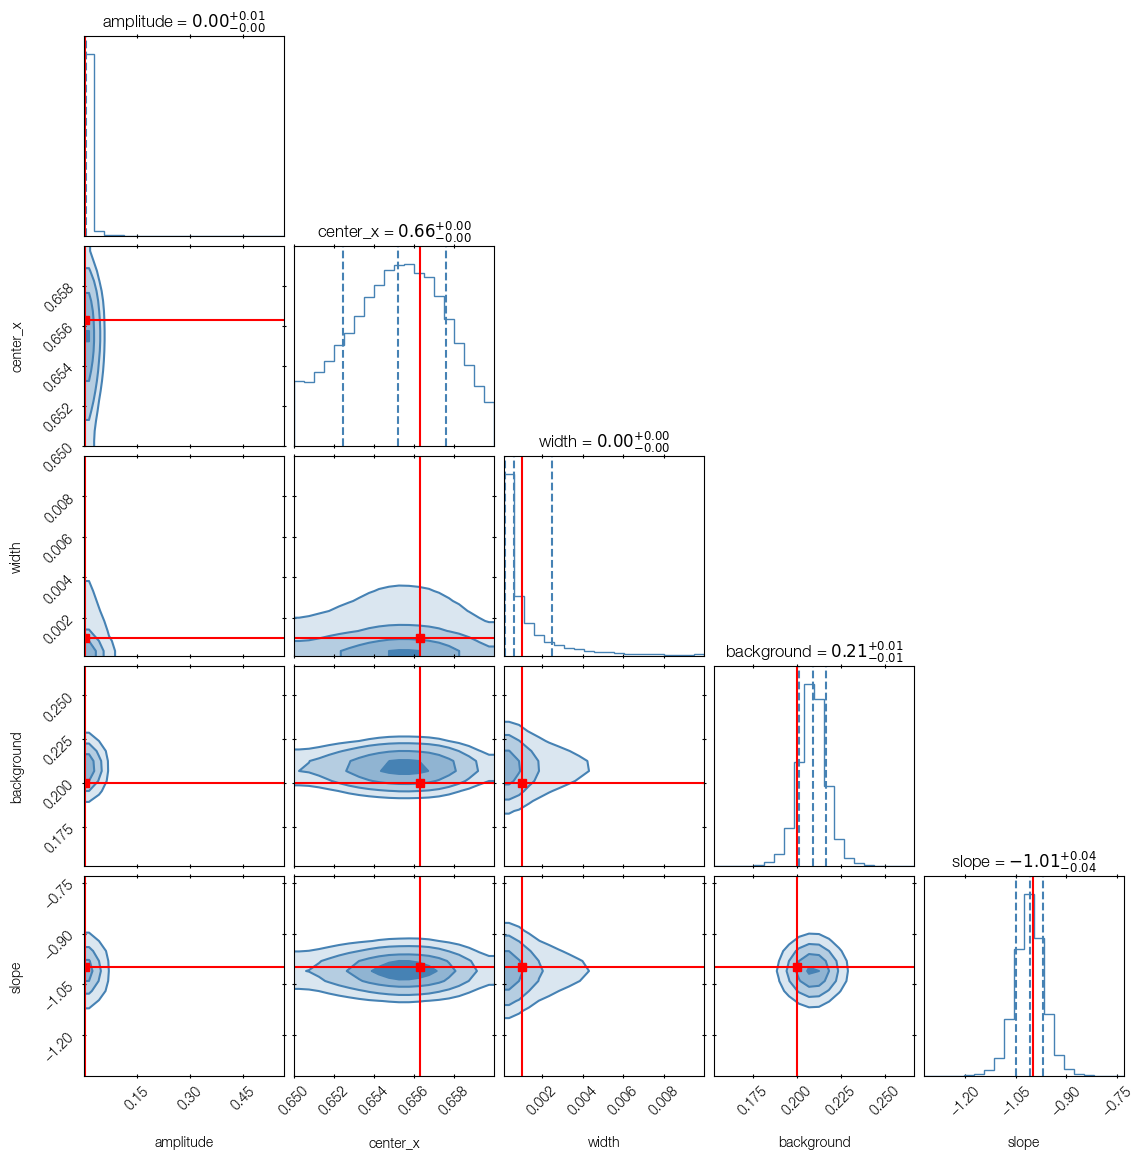

In [23]:
corner.corner(
    posterior_samples_theta,
    labels=parameter_names,
    truths=theta_true,
    truth_color="red",
    show_titles=True,
    quantiles=[0.16, 0.5, 0.84],
    color="steelblue",
    plot_datapoints=False,
    fill_contours=True,
    smooth=1.0,
);

### Getting the NPE distribution parameters

The above is a Kumaraswamy-Logistic chained distribution defined on the unit hypercube. It can be summarized with a few distribution parameters for each model parameters.

In [24]:
from ultranest.simbase.minisbi.nested import get_distribution_parameters, KLPTransform

In [25]:
distribution_parameters = get_distribution_parameters(model, obs_spectrum)

In [26]:
distribution_parameters

{'loc': [0.9677473306655884,
  0.27672627568244934,
  0.19500614702701569,
  0.5872949957847595,
  0.3659431040287018],
 'scale': [0.2043338119983673,
  0.09192689508199692,
  0.09408794343471527,
  0.004435378592461348,
  0.013627054169774055],
 'a': [1.0740731954574585,
  1.3751872777938843,
  1.5721242427825928,
  0.22820907831192017,
  0.43438252806663513],
 'b': [0.2384941726922989,
  3.7631149291992188,
  5.234200954437256,
  0.42766571044921875,
  0.2740660607814789]}

It might be useful to store for reuse:

In [27]:
import json
with open(folder + '/distribution.json', 'w') as f:
    json.dump(distribution_parameters, f)

### Checking the SBI model: rank histogram

First, we check that the model gives reliable posteriors, with a rank histogram.

We generate from the prior, and sample posterior samples. Ideally, the rank of the prior samples and the rank of the posterior samples are on a line (see [Simulation-based calibration paper](https://arxiv.org/abs/1804.06788)).

In [28]:
from ultranest.simbase.minisbi.plot import rank_histogram

Rank histogram:   0%|                                                                          | 0/5000 [00:00<?, ?sim/s]/home/user/Downloads/mininest/ultranest/simbase/minisbi/logistic.py:37: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-np.clip(x, -500.0, 500.0)))
Rank histogram: 100%|█████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 8801.27sim/s]


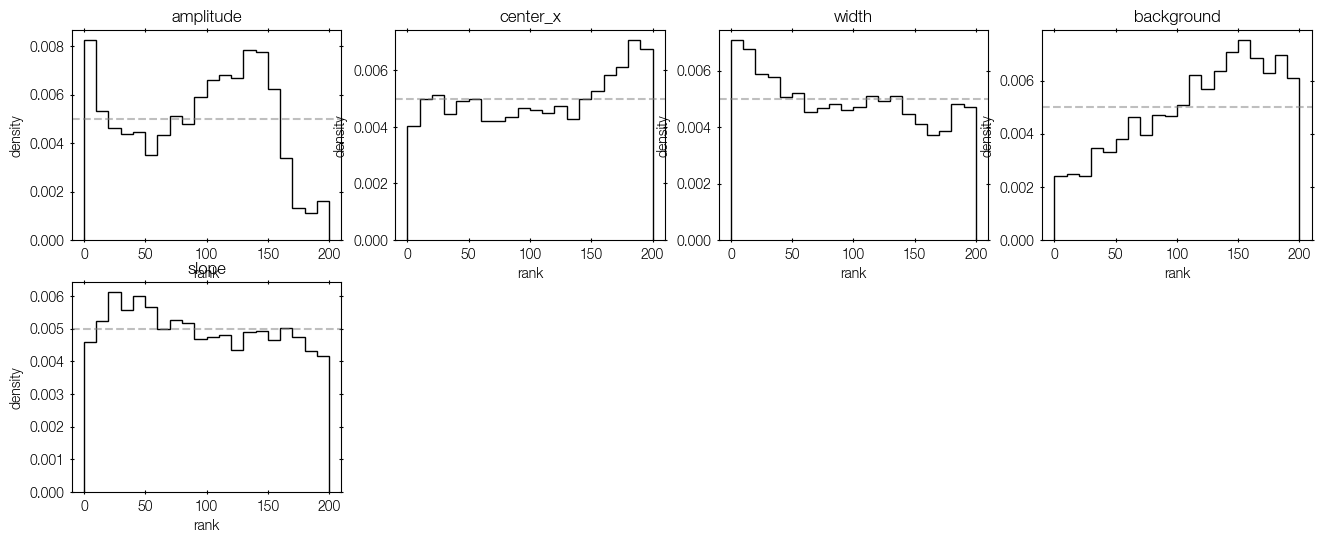

In [29]:
ranks, fig, axes = rank_histogram(
    model=model,
    generate_noiseless_batch=generate_noiseless_batch,
    inject_noise=inject_noise,
    prior_transform=prior_transform,
    n_params=N_PARAMS,
    folder=folder,
    n_test=5000,
    seed=98765,
    param_names=parameter_names,
    n_bins=20,
)
fig;

These histograms should be flat. 

If they a U-shaped, the posterior is over-confident. 
If they are inverse U-shaped, the posterior is under-confident.

You might be able to improve this by choosing a larger neural network.

In [30]:
print("  Per-parameter rank statistics:")
for i, name in enumerate(parameter_names):
    print(f"    {name:12s}: mean={ranks[:, i].mean():.1f}  "
          f"std={ranks[:, i].std():.1f}  expected_mean=100.0")

  Per-parameter rank statistics:
    amplitude   : mean=91.4  std=52.6  expected_mean=100.0
    center_x    : mean=105.9  std=59.8  expected_mean=100.0
    width       : mean=92.2  std=59.1  expected_mean=100.0
    background  : mean=117.0  std=53.5  expected_mean=100.0
    slope       : mean=95.6  std=57.3  expected_mean=100.0


### Checking the SBI model: coverage test

Next, we check whether the x% credible intervals contain the true value in x% of cases:

In [31]:
from ultranest.simbase.minisbi.plot import parameter_coverage_test

Coverage test: 100%|████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 9391.93sim/s]


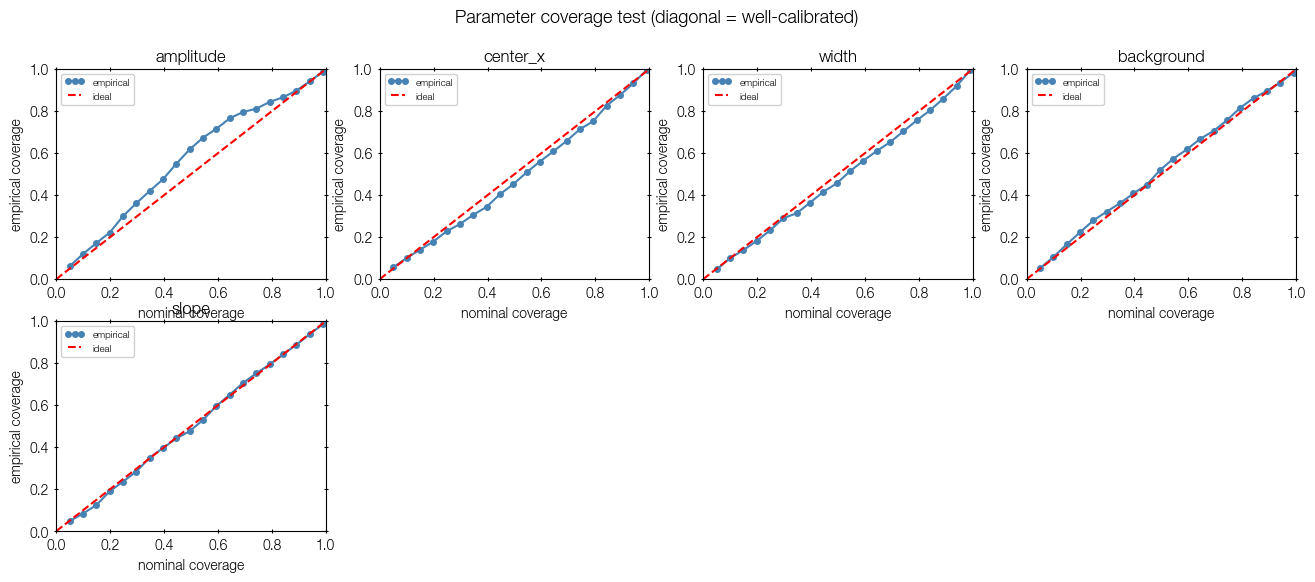

In [32]:
coverage, fig, axes = parameter_coverage_test(
    model=model,
    generate_noiseless_batch=generate_noiseless_batch,
    inject_noise=inject_noise,
    prior_transform=prior_transform,
    n_params=N_PARAMS,
    folder=folder,
    n_test=500,
    credible_levels=np.linspace(0.05, 0.99, 20).tolist(),
    seed=11223,
    param_names=parameter_names,
)
fig;

These should follow the diagonal (red dashed).

Most of them look good. The amplitude parameter is slightly off, but not too wild.

If not, the posterior for that parameter is not well-calibrated (too narrow or too wide error bars). You might be able to improve this by choosing a larger neural network.

In [33]:
print("  Empirical coverage at nominal 90% level:")
levels = np.linspace(0.05, 0.99, 20)
idx_90 = np.argmin(np.abs(levels - 0.90))
for i, name in enumerate(parameter_names):
    print(f"    {name:12s}: {coverage[idx_90, i]:.3f}  (nominal=0.900)")


  Empirical coverage at nominal 90% level:
    amplitude   : 0.898  (nominal=0.900)
    center_x    : 0.876  (nominal=0.900)
    width       : 0.860  (nominal=0.900)
    background  : 0.896  (nominal=0.900)
    slope       : 0.888  (nominal=0.900)


### ultranest-sbi: SBI-accelerated nested sampling

### Setting up the accelerated inference

Here we run nested sampling using the NPE posterior as a reparameterisation.

This allows nested sampling to start at a shrunk-down prior. To ensure identical inference as if we had started with the full prior, we need to correct the likelihood function by a penalty.

* The nested sampler samples t ~ Uniform(0,1)^d.
* The prior transform maps:   t -> u -> theta
* The log-likelihood includes a correction: loglike(theta) - log q(u | x_obs)

The correction ensures that the evidence integral and posterior samples
are correct with respect to the original flat prior over u (and thus
the physical prior over theta).

In [34]:
# a helper object defining the distribution, its transform and log-posterior
klp_transform = KLPTransform(**distribution_parameters)

In [35]:
class _State:
    last_t = None
state = _State()

# warp the prior by the NPE distribution
def warped_prior_transform(t):
    # keep the last state for likelihood
    state.last_t = t.copy()
    # [0,1]^d -> [0,1]^d with the SBI posterior warp
    u     = klp_transform.transform(t).astype(float)
    # [0,1]^d -> physical parameters
    theta = prior_transform(u)
    return theta

# correct the likelihood for the warp
def corrected_log_likelihood(theta):
    mp   = generate_mean_and_noise(theta=theta, idx=0, seed=0)
    # compute our model likelihood
    logL = loglikelihood(mp, obs_spectrum)
    # compute neural posterior density
    log_jac = klp_transform.log_jacobian(state.last_t)
    return logL + log_jac


## Setting up the accelerated sampler

Build our accelerated ultranest-sbi sampler:

In [36]:
sampler = ultranest.ReactiveNestedSampler(
    parameter_names,
    corrected_log_likelihood,
    warped_prior_transform,
    log_dir=folder,
    resume='overwrite',
)

Torch modified the logging to show all messages, let's suppress that

In [37]:
import logging

logger = logging.getLogger('ultranest')
logger.setLevel(logging.ERROR) 
#logging.basicConfig(level=logging.INFO, stream=sys.stderr) 

### Run the accelerated ultranest-sbi sampler

In [38]:
results = sampler.run(frac_remain=0.5, max_num_improvement_loops=0)

### Posterior distribution:

Looking at the posterior distribution of the ultranest-sbi sampler, it is much narrower than the SBI one:

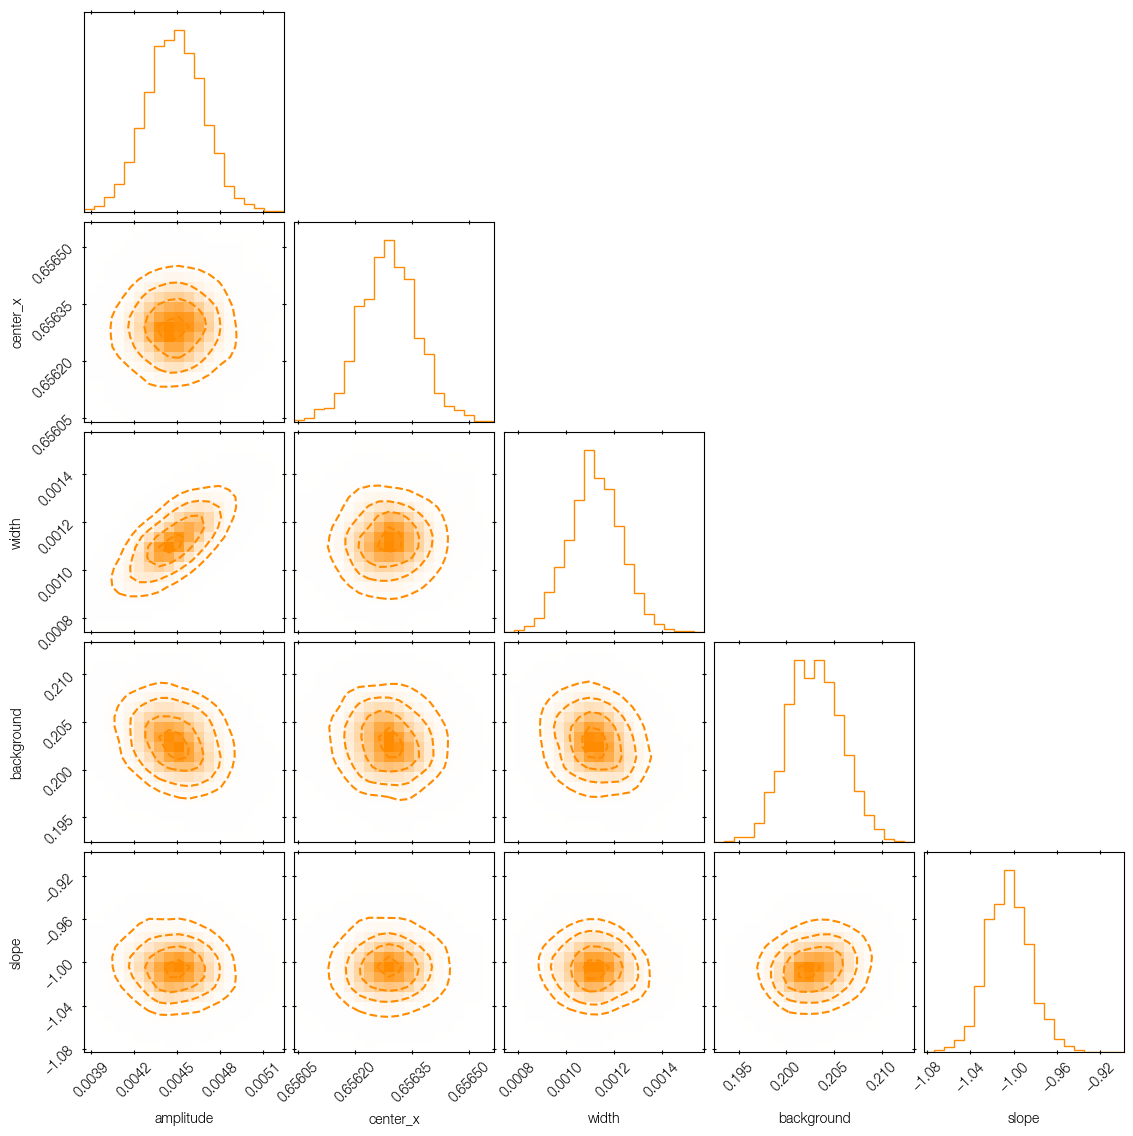

In [39]:
corner.corner(
    results['samples'],
    labels=parameter_names,
    color="darkorange",
    plot_datapoints=False,
    fill_contours=False,
    smooth=1.0,
    contour_kwargs={"linestyles": "dashed"},
);

### Combined posterior distribution

Comparing them on the same plot, the SBI posterior is extremely wide, while ultranest manages to zoom in and get the full information.

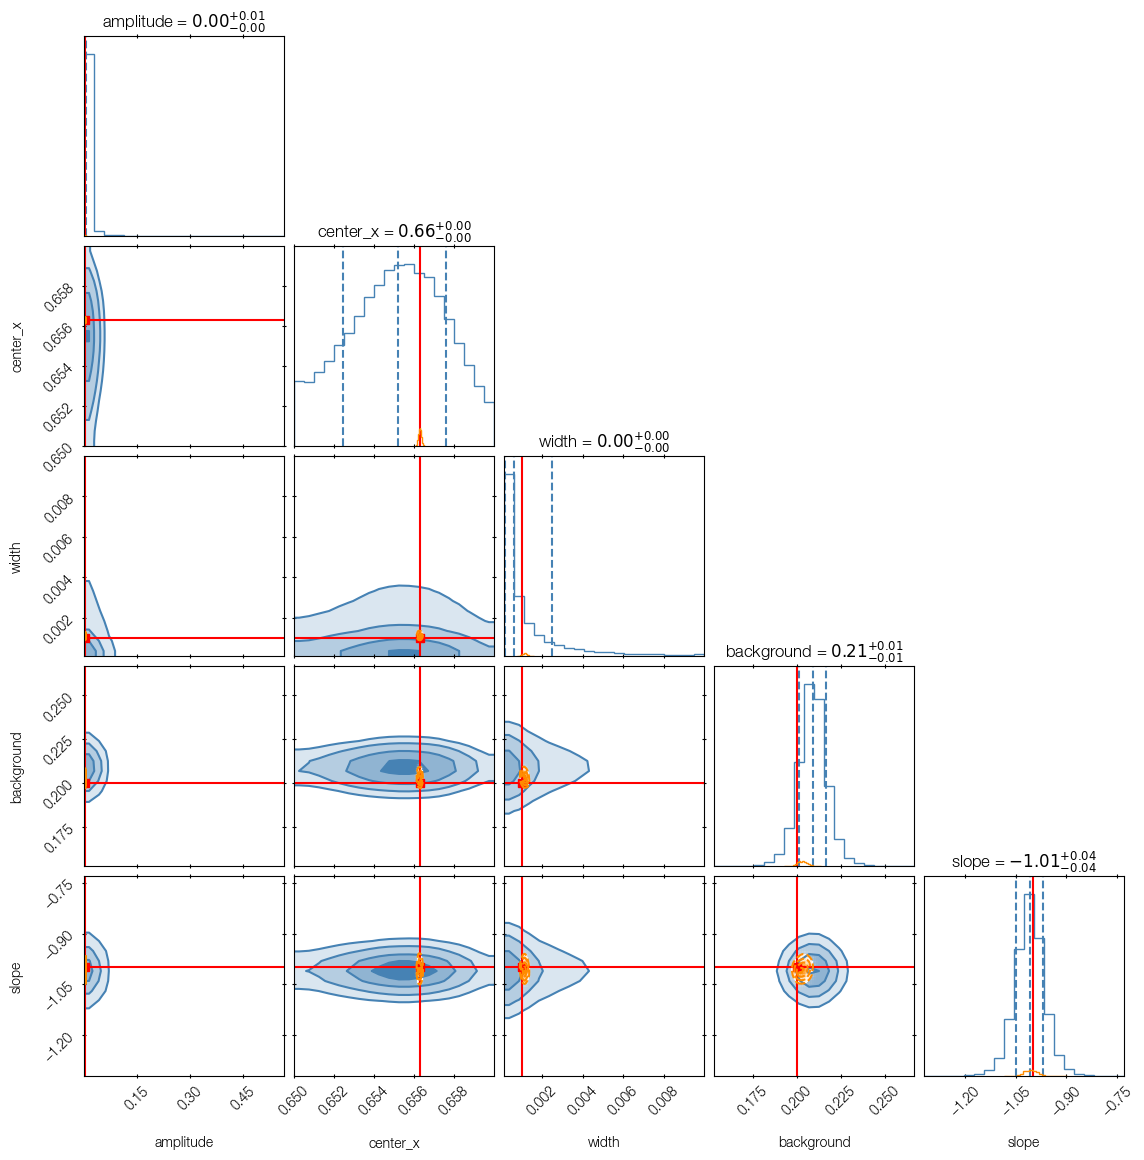

In [40]:
figure = corner.corner(
    posterior_samples_theta,
    labels=parameter_names,
    truths=theta_true,
    truth_color="red",
    show_titles=True,
    quantiles=[0.16, 0.5, 0.84],
    color="steelblue",
    plot_datapoints=False,
    fill_contours=True,
    smooth=1.0,
)
# overplot nested sampling posterior on the same figure
corner.corner(
    results['samples'],
    labels=parameter_names,
    fig=figure,
    color="darkorange",
    plot_datapoints=False,
    fill_contours=False,
    smooth=1.0,
    contour_kwargs={"linestyles": "dashed"},
);

Notice that the ultranest-sbi posterior (orange) is much narrower than the SBI posterior (blue), because SBI lost a lot of information. Nevertheless, the blue distribution provides a useful starting point for nested sampling.

## Takeaways

* In addition to the usual model and its likelihood, we defined a data simulator that can generate data.

* We have learned to train a simulation-based inference (SBI) neural posterior estimator (NPE) model for obtaining a fast posterior distribution.

* We checked that SBI posterior is amortized to behave well across the entire prior.

* We used the SBI posterior on our data to get a starting point for a posterior distribution. This distribution has lost some information.

* We used ultranest on top of the SBI posterior to get the posterior samples from the true posterior.

* This ultranest-sbi approach effectively "skips" many initial nested sampling iterations, zooming into a data-driven guess for the posterior location. Because the SBI posterior is virtually always too wide, nested sampling is then fast to integrate to the actual posterior bulk.

**Limitations**: The posterior distribution used by the neural network is factorized and not optimal for challenging distributions. With a different, more sophisticated sbi package, better neural posteriors could be learned, but that would mean more complexity as well.

When using this in publications, please refer to it as **ultranest-sbi**, to distinguish it from ultranest.

#### Further reading

* https://arxiv.org/abs/1804.06788, "Validating Bayesian Inference Algorithms with Simulation-Based Calibration", Talts e al., 2018
* https://doi.org/10.1073/pnas.1912789117 "The frontier of simulation-based inference", Cranmer, Brehmer, Louppe, 2020